# Data Augmentation 적용 RPS

## 모듈 로딩

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
import os
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.20.0
Matplotlib Version :3.10.0


## g-drive 마운트

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


## RPS 데이터셋 준비

In [3]:
# !unzip -q -o /content/drive/MyDrive/ai_project/files/DataSet.zip
# !ls /content
# !ls /content/ㄱ | head

In [7]:
# files_path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  # !unzip -q -o /content/drive/MyDrive/ai_project/files/DataSet.zip
  !unzip -q -o /content/drive/MyDrive/ai_project/files/DataSet_hand_224_png.zip
  files_path = '/content'
else :
  # files_path = '../files/DataSet'
  pass

##ㄱ ~ ㅢ를 0 ~ 30으로 변경

In [8]:
class_names = [
    "ㄱ", "ㄴ", "ㄷ", "ㄹ", "ㅁ",
    "ㅂ", "ㅅ", "ㅇ", "ㅈ", "ㅊ",
    "ㅌ", "ㅍ", "ㅋ", "ㅎ",
    "ㅏ", "ㅑ", "ㅓ", "ㅕ",
    "ㅗ", "ㅛ", "ㅜ", "ㅠ",
    "ㅡ", "ㅣ",
    "ㅐ", "ㅒ", "ㅔ", "ㅖ",
    "ㅚ", "ㅟ", "ㅢ"
]

for idx, cls in enumerate(class_names):
    os.rename(
        f'{files_path}/{cls}',
        f'{files_path}/{idx}'
    )

## 폴더 별로 파일 읽어 데이터화 진행

In [9]:
IMG_SIZE = 224

In [11]:
# print(files_path)
# !find /content/drive -name "DataSet_hand_224_png"


# import os
# import glob

# class_names = sorted(os.listdir(files_path))

# print(class_names)


# first = True

# for label, cls in enumerate(class_names):
#     path = os.path.join(files_path, cls, '*.*')

#     files = glob.glob(path)

#     print(cls, len(files))

#     if len(files) == 0:
#         continue

#     tmpx = np.array([
#         cv2.resize(
#             cv2.cvtColor(cv2.imread(x), cv2.COLOR_BGR2RGB),
#             (IMG_SIZE, IMG_SIZE)
#         )
#         for x in files
#     ])

#     tmpy = np.array([label] * len(files))

#     xtrain, xtest, ytrain, ytest = train_test_split(
#         tmpx, tmpy,
#         test_size=0.2,
#         random_state=123
#     )

#     if first:
#         train_data = xtrain
#         train_labels = ytrain
#         test_data = xtest
#         test_labels = ytest
#         first = False
#     else:
#         train_data = np.concatenate((train_data, xtrain))
#         train_labels = np.concatenate((train_labels, ytrain))
#         test_data = np.concatenate((test_data, xtest))
#         test_labels = np.concatenate((test_labels, ytest))



%%time
first = True
for ind in range(0, 31, 1):
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)
    tmpx = np.array([(cv2.resize(cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE,IMG_SIZE))) for x in files])
    tmpy = np.array([ind] * len(files))

    xtrain, xtest, ytrain, ytest = train_test_split(tmpx, tmpy, test_size=0.2, random_state=123)

    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))

/content/0/*.*
/content/1/*.*
/content/2/*.*
/content/3/*.*
/content/4/*.*
/content/5/*.*
/content/6/*.*
/content/7/*.*
/content/8/*.*
/content/9/*.*
/content/10/*.*
/content/11/*.*
/content/12/*.*
/content/13/*.*
/content/14/*.*
/content/15/*.*
/content/16/*.*
/content/17/*.*
/content/18/*.*
/content/19/*.*
/content/20/*.*
/content/21/*.*
/content/22/*.*
/content/23/*.*
/content/24/*.*
/content/25/*.*
/content/26/*.*
/content/27/*.*
/content/28/*.*
/content/29/*.*
/content/30/*.*
CPU times: user 26.7 s, sys: 7.13 s, total: 33.9 s
Wall time: 34.2 s


In [12]:
#d = np.load('/content/drive/MyDrive/ai/files/RPS_Dataset.npz')

In [13]:
# train_data, train_labels, test_data, test_labels = d.values()

## 데이터 확인

In [14]:
# Normalization 처리 안함 (모델 내에서 -1 ~ 1로 변환 처리함)
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(9421, 224, 224, 3)
(9421,)
(2376, 224, 224, 3)
(2376,)


## ImageDataGenerator 객체 생성

In [15]:
img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
                horizontal_flip=True,        # 좌우 반전 여부 설정
                rotation_range=0.2,          # 회전 범위 설정
                width_shift_range=0.1,       # 좌우로 이동할 범위 설정
                height_shift_range=0.1,      # 상하로 이동할 범위 설정
                brightness_range=(0.1, 0.9), # 밝기 범위 설정
                zoom_range=0.2               # 줌 범위 설정
                )                            # 이외에도 다양한 설정 가능

train_gen = img_gen_train.flow(train_data, train_labels, batch_size=64, seed = 1)

## 모델 생성


In [16]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor = x
)
base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(31, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

/tmp/ipykernel_573/489855323.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ subtract[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis

 Total params: 2,425,951 (9.25 MB)

 Trainable params: 167,967 (656.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 모델 컴파일

In [17]:
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 학습 전 상황

In [18]:
def Make_Result_Plot(suptitle, data, label, y_max):
    size = data.shape[0]//10
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        cnt = idx * size + size//2
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt]))

75/75 ━━━━━━━━━━━━━━━━━━━━ 37s 229ms/step


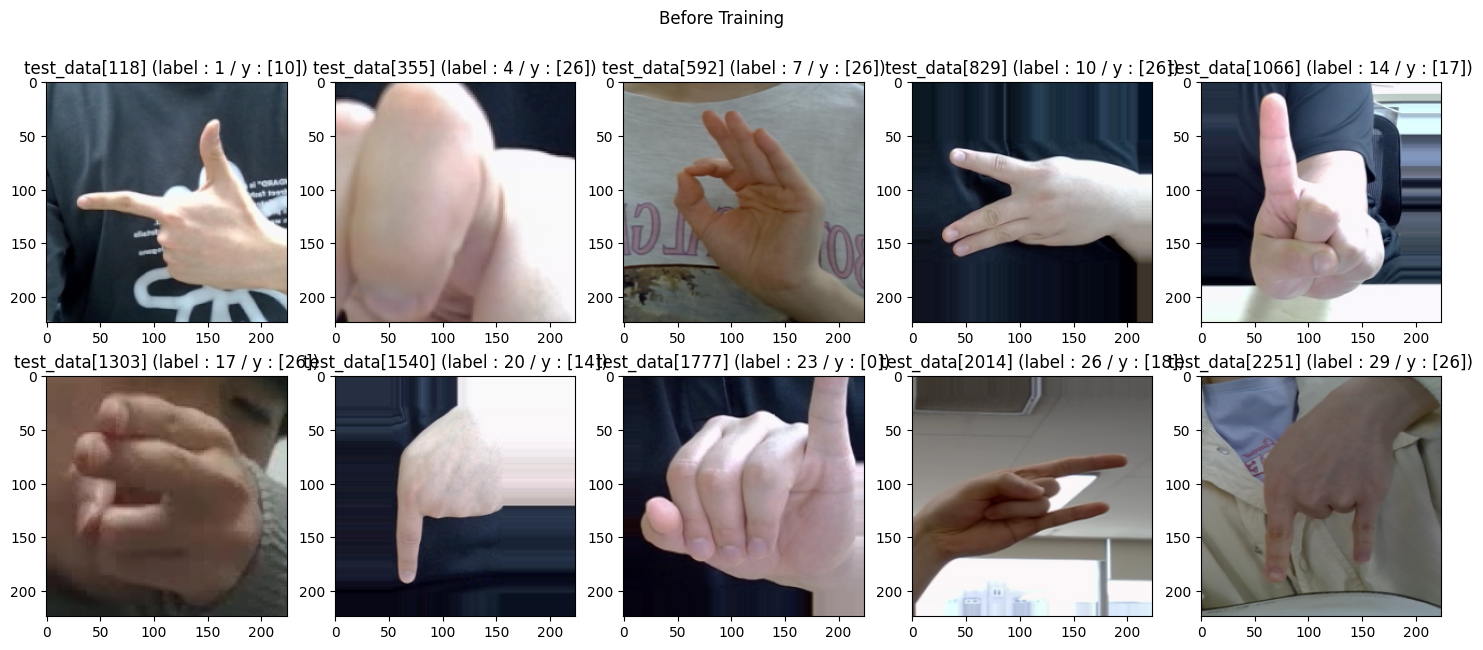

In [19]:
y_out = model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

## 콜백 설정

In [20]:
savedModelName = 'Hand_RPS_MobileNetV2.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(savedModelName,
                                    save_best_only=True)
]

## 모델 학습

In [21]:
%%time
history = model.fit(train_gen, epochs=30,
                    # batch_size=64,
                    callbacks=callbacks,
                    validation_data=(test_data, test_labels))

Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.1178 - loss: 3.2179 - val_accuracy: 0.2934 - val_loss: 2.6807
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 128s 863ms/step - accuracy: 0.3322 - loss: 2.3986 - val_accuracy: 0.5265 - val_loss: 1.9180
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 134s 902ms/step - accuracy: 0.4834 - loss: 1.8502 - val_accuracy: 0.6326 - val_loss: 1.4822
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 148s 993ms/step - accuracy: 0.5676 - loss: 1.5372 - val_accuracy: 0.6907 - val_loss: 1.2383
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 145s 983ms/step - accuracy: 0.6240 - loss: 1.3175 - val_accuracy: 0.7298 - val_loss: 1.0761
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 140s 949ms/step - accuracy: 0.6636 - loss: 1.1739 - val_accuracy: 0.7635 - val_loss: 0.9384
Epoch 7/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 131s 884ms/step - accuracy: 0.7022 - loss: 1.0497 - val_accuracy: 0.7950 - val_loss: 0.8419
Epoch 8/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 133s 900ms/step - accuracy: 0.7208 - lo

## Ploting : Cost/Training Count

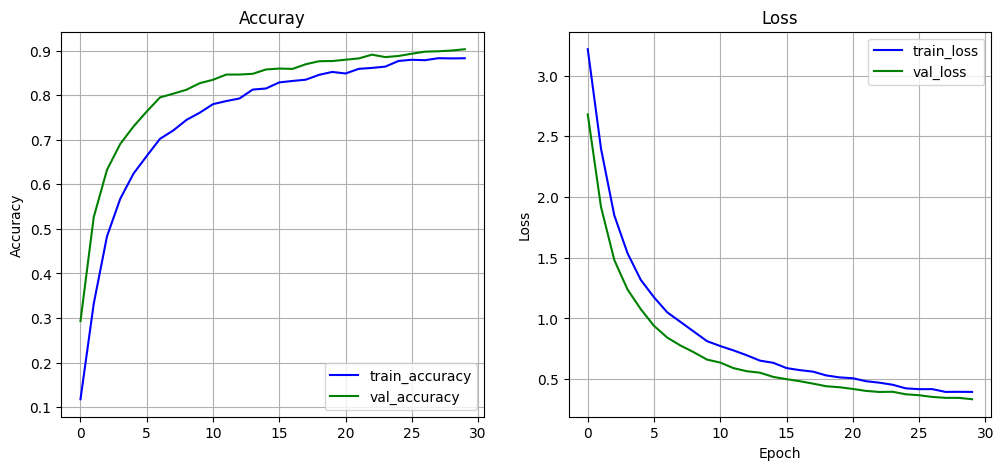

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('Accuray')
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')
# plt.ylim([0,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(1, 2, 2)
plt.title('Loss')
plt.plot(history.history['loss'], 'b', label='train_loss')
plt.plot(history.history['val_loss'], 'g', label='val_loss')
# plt.ylim([0,5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

## best 모델 로딩 및 테스트

In [23]:
model_best = tf.keras.models.load_model (savedModelName)

75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step


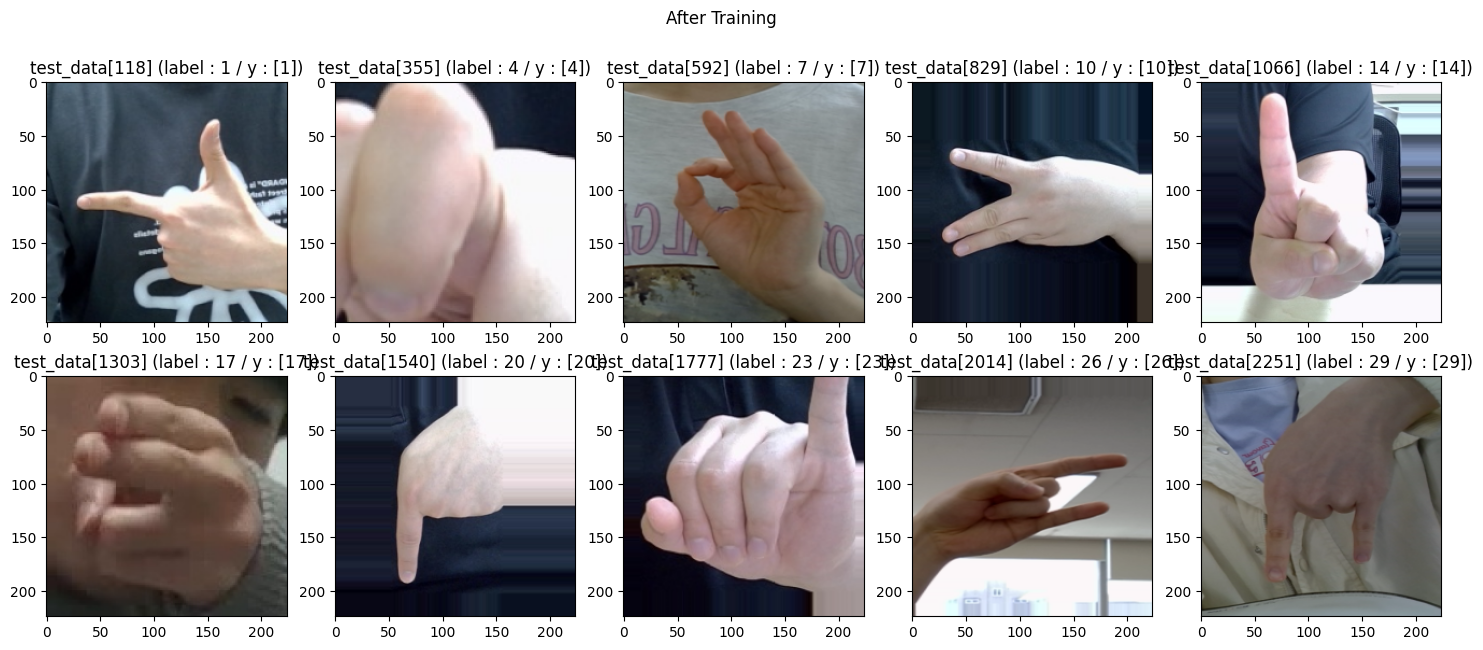

In [24]:
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)

## best 모델 백업

In [25]:
# save_dir: 다른 경로에 저장하려면, 아래 경로를 수정하세요
if colab :
  save_dir = '/content/drive/MyDrive/files/save/'
else :
  save_dir = '../files/save/'

In [26]:
# copy saved mode
cpCmd = f'cp {savedModelName} {save_dir}'
print(cpCmd)
!{cpCmd}

cp Hand_RPS_MobileNetV2.keras /content/drive/MyDrive/files/save/
cp: cannot create regular file '/content/drive/MyDrive/files/save/': No such file or directory


## ONNX 모델로 변환

In [27]:
!pip -q install tf2onnx
!pip -q install onnx onnxsim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.8 MB/s eta 0:00:00


In [28]:
onnx_model_name = 'RPS_MobileNetV2_Augmentation.onnx'

In [29]:
import tf2onnx

# 2. 모델의 입력 형태(Input Signature) 정의
# 주의: (None, 224, 224, 3) 부분은 실제 모델의 입력 이미지 크기에 맞게 수정해야 합니다.
spec = (tf.TensorSpec((1, 224, 224, 3), tf.float32, name="input"),)

# 3. ONNX로 변환 및 저장
model_proto, _ = tf2onnx.convert.from_keras(
    model_best,
    input_signature=spec,
    opset=18,
    output_path=onnx_model_name
)

print("ONNX 변환 완료!")

ONNX 변환 완료!


## ONNX Sim

In [30]:
onnxsim_model_name = 'RPS_MobileNetV2_Augmentation.sim.onnx'

In [31]:
cmd = f'onnxsim {onnx_model_name} {onnxsim_model_name}'
!{cmd}

Installing onnxruntime by `/usr/bin/python3 -m pip install onnxruntime`, please 
wait for a moment..
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 20.1 MB/s eta 0:00:00
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 27             │ 27               │
│ Clip       │ 35             │ 35               │
│ Constant   │ 131            │ 130              │
│ Conv       │ 52             │ 52               │
│ Gemm       │ 2              │ 2                │
│ Mul        │ 18             │ 18               │
│ Pad        │ 4              │ 0                │
│ ReduceMean │ 1              │ 1                │
│ Relu       │ 1              │ 1                │
│ Softmax    │ 1              │ 1                │
│ Sub        │ 1              │ 1                │
│ Transpose  │ 2              │ 2                │
│ Model 

## Download ONNX models

In [32]:
from google.colab import files

In [33]:
tarball_name = 'RPS_MobileNetV2_Augmentation.tar.gz'
cmd = f'tar -zcvf {tarball_name} {onnx_model_name} {onnxsim_model_name}'
!{cmd}

RPS_MobileNetV2_Augmentation.onnx
RPS_MobileNetV2_Augmentation.sim.onnx


In [34]:
files.download(tarball_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>